# Supply Chain Backorder Prediction

## A Complete Guide: Problem Definition, Dataset Analysis, and Machine Learning Model

**Dataset Source**: Kaggle - Backorder Prediction Dataset  
**Objective**: Predict which products will go on backorder to optimize inventory management

## Part 1: Understanding the Business Problem

### What is Backorder?

**Backorder** occurs when a customer orders a product that is **temporarily out of stock**. The company must:
- Wait to receive new inventory
- Fulfill the order later
- Potentially lose the sale or customer satisfaction

### The Business Impact

**Problems Caused by Backorders**:
- Loss of revenue and customer satisfaction
- Increased operational costs (expedited shipping)
- Damage to brand reputation
- Wasted resources managing unfulfilled orders

**Why Prediction Matters**:
- **Prevent stockouts**: Reorder inventory before backorders occur
- **Optimize inventory**: Avoid overstocking (which wastes money)
- **Plan resources**: Allocate staff and warehouse space effectively
- **Improve cash flow**: Better inventory turnover
- **Reduce costs**: Avoid expedited shipping and rush orders

### Project Goal

**Build a machine learning model that predicts BEFORE a product goes on backorder**

- **Input**: Product inventory and sales data
- **Output**: Probability that product will go on backorder (Yes/No)
- **Use Case**: Alert supply chain team to reorder inventory proactively

---

## Part 2: Complete Dataset Feature Explanation

### All 23 Features Explained in Detail

#### **Section A: Product Identification**

**1. sku** (Stock Keeping Unit)
- Unique identifier for each product
- Example: 1026827, 1043384
- Used to distinguish between different products
- *Why important*: Each product has different demand patterns

---

#### **Section B: Current Inventory Status**

**2. national_inv** (National Inventory)
- Current quantity in stock across all warehouses
- Numerical value (0, 2, 7, 8, 13, 1095, etc.)
- *Why important*: Low inventory = higher backorder risk
- If inventory is 0 or very low → HIGH RISK of backorder

**3. lead_time**
- Days to receive new inventory from supplier
- Example: 8, 9 days
- Missing values (-99 or blank) indicate no supplier available
- *Why important*:
  - LONG lead time + LOW inventory = HIGH backorder risk
  - SHORT lead time = can reorder quickly
  - MISSING lead time = no way to replenish stock

**4. in_transit_qty** (Quantity In Transit)
- Items on the way from supplier (not yet in warehouse)
- Represents incoming inventory
- *Why important*: Stock that's coming soon reduces immediate backorder risk
- high in_transit_qty = relief is coming

---

#### **Section C: Demand Forecasting**

**5-7. forecast_3_month, forecast_6_month, forecast_9_month**
- Predicted demand for next 3, 6, and 9 months
- Generated by demand planning system
- *Why important*:
  - HIGH forecast + LOW inventory = backorder risk
  - Shows expected customer demand
  - Used to plan reorder quantities

---

#### **Section D: Historical Sales Data**

**8-11. sales_1_month, sales_3_month, sales_6_month, sales_9_month**
- ACTUAL sales in past periods
- Shows true customer demand history
- *Why important*:
  - HIGH historical sales = strong demand
  - Volatile sales = unpredictable demand (harder to manage)
  - Shows product popularity
  - If sales > inventory → likely to backorder

---

#### **Section E: Inventory Safety Management**

**12. min_bank** (Minimum Bank Level)
- Safety stock level (minimum inventory to keep)
- Set by inventory planners
- *Why important*:
  - If inventory < min_bank → safety stock depleted
  - Backorder risk increases
  - Example: min_bank=4 but national_inv=1 = LOW SAFETY

---

#### **Section F: Problem Indicators**

**13. potential_issue** (Categorical: Yes/No)
- Flag indicating known supply chain issues
- Examples: supplier quality problems, shipping delays
- *Why important*: Issues = higher backorder likelihood

**14. pieces_past_due** (Numerical)
- Number of items ordered but NOT yet delivered
- Overdue orders waiting fulfillment
- *Why important*:
  - HIGH pieces_past_due = unfulfilled demand
  - Indicates backorder situation already happening
  - Strong predictor of backorder status

---

#### **Section G: Performance Metrics**

**15. perf_6_month_avg** (Performance 6-Month Average)
- Supplier fill rate (0.0 to 1.0)
- 0.99 = 99% of orders filled on time
- -99 = missing data
- *Why important*:
  - LOW score = unreliable supplier
  - HIGH score = reliable, consistent deliveries

**16. perf_12_month_avg** (Performance 12-Month Average)
- Longer-term supplier reliability
- Shows consistency over a full year
- *Why important*: Long-term supplier reliability

---

#### **Section H: Logistics & Operational Data**

**17. local_bo_qty** (Local Backorder Quantity)
- Backorders already at regional/local level
- *Why important*:
  - If local_bo_qty > 0 = backorders already happening locally
  - Strong indicator product will go nationally on backorder

---

#### **Section I: Risk Flags**

**18. deck_risk** (Categorical: Yes/No)
- Risk related to deck (warehouse staging area)
- Space constraints or handling issues
- *Why important*: Logistics bottleneck = delayed deliveries

**19. oe_constraint** (Categorical: Yes/No)
- Original Equipment constraint
- Product used in manufacturing (OEM products)
- Critical for production lines
- *Why important*: OEM backorders cause production shutdowns

**20. ppap_risk** (Categorical: Yes/No)
- PPAP = Production Part Approval Process
- Supplier certification/approval issues
- *Why important*: Regulatory delays = supply chain disruption

**21. stop_auto_buy** (Categorical: Yes/No)
- Automatic purchasing system is DISABLED
- Means manual ordering required
- *Why important*:
  - Manual process = slower reordering
  - More likely to miss reorder windows
  - Higher backorder risk

**22. rev_stop** (Categorical: Yes/No)
- Revenue stop flag
- Profit/loss issues with this product
- *Why important*: Low-profit items may not get priority

---

#### **Section J: Target Variable (What We Predict)**

**23. went_on_backorder** (Categorical: Yes/No) ⭐
- **TARGET VARIABLE - THIS IS WHAT WE PREDICT**
- Yes = Product went on backorder
- No = Product never went on backorder
- *Note*: This is HIGHLY IMBALANCED
  - We need special handling for imbalanced classification

---

### Feature Summary Table

| Category | Feature | Type | Example |
|----------|---------|------|----------|
| ID | sku | int | 1026827 |
| **Inventory** | national_inv | int | 0, 2, 7 |
| **Logistics** | lead_time | int | 8, 9 days |
| | in_transit_qty | int | 0, 5 units |
| **Demand** | forecast_3/6/9_month | int | 0, 100, 500 |
| **Sales History** | sales_1/3/6/9_month | int | 0, 50, 200 |
| **Safety** | min_bank | int | 0, 1, 4 |
| **Issues** | potential_issue | str | Yes/No |
| | pieces_past_due | int | 0, 100 |
| **Performance** | perf_6/12_month_avg | float | 0.99, -99 |
| **Backorder** | local_bo_qty | int | 0, 50 |
| **Risks** | deck_risk, oe_constraint, etc. | str | Yes/No |
| **TARGET** | went_on_backorder | str | Yes/No |

---

## Part 3: Implementation - Step by Step

### Step 1: Import Required Libraries

In [1]:
import pandas as pd                      
import numpy as np                                  
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../raw_csv/Kaggle_Training_Dataset_v2.csv') 
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

C:\Users\pc\AppData\Local\Temp\ipykernel_28200\3714851590.py:2: DtypeWarning: Columns (0: sku) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../raw_csv/Kaggle_Training_Dataset_v2.csv')


Dataset Shape: 1687861 rows x 23 columns


In [ ]:
df.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No


In [79]:
# Detailed information about dataset
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1687861 entries, 0 to 1687860
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1687861 non-null  object 
 1   national_inv       1687860 non-null  float64
 2   lead_time          1586967 non-null  float64
 3   in_transit_qty     1687860 non-null  float64
 4   forecast_3_month   1687860 non-null  float64
 5   forecast_6_month   1687860 non-null  float64
 6   forecast_9_month   1687860 non-null  float64
 7   sales_1_month      1687860 non-null  float64
 8   sales_3_month      1687860 non-null  float64
 9   sales_6_month      1687860 non-null  float64
 10  sales_9_month      1687860 non-null  float64
 11  min_bank           1687860 non-null  float64
 12  potential_issue    1687860 non-null  str    
 13  pieces_past_due    1687860 non-null  float64
 14  perf_6_month_avg   1687860 non-null  float64
 15  perf_12_month_avg  1687860 no

### Step 3: Exploratory analysis

#### <u>1-National_inv</u>  

Current inventory available in stock.

Business importance:
Products with very low inventory are more likely to go on backorder because demand may exceed available stock.

In [ ]:
from scipy.stats import skew
percentiles = [0.25,0.5,0.75,0.9,0.95,0.99]
def descriptive_stats(col):
    print(f"Mean Inventory : {df[col].mean():.2f}")
    print(f"Median Inventory: {df[col].median():.2f}")
    print(f"Minimum Inventory: {df[col].min()}")
    print(f"Maximum Inventory: {df[col].max()}")
    print(f"Standard Deviation : {df[col].std()}")
    print(f"Range : {df[col].max()-df[col].min()}")
    print(f"percentiles : \n{df[col].quantile(percentiles)}")

    print("="*60)
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())
    

In [ ]:
def detect_outiliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print("Outliers count:", len(outliers))


In [ ]:
def distribution_plots(col):
    plt.figure(figsize=(15,12))
    """ 
    you can observe
    Bell shape? 
    Right skew?
    Left skew?
    Multiple peaks?
    Long tail?
    """
    plt.subplot(2,2,1)
    plt.title("Distribution")
    sns.histplot(df[col],kde=True,bins=40)

    """  
    Shows:Median ,IQR,Outliers
    """
    plt.subplot(2,2,2)
    plt.title("Boxplot")
    sns.boxplot(x=df[col])

    """ 
    Shows:Density,Spread,Shape of the distribution
    """
    plt.subplot(2,2,3)
    plt.title("Violin Plot")
    sns.violinplot(x=df[col])

    

In [83]:
descriptive_stats("national_inv")

Mean Inventory : 496.11
Median Inventory: 15.00
Minimum Inventory: -27256.0
Maximum Inventory: 12334404.0
Standard Deviation : 29615.233830794277
Range : 12361660.0
percentiles : 
0.25       4.0
0.50      15.0
0.75      80.0
0.90     359.0
0.95     922.0
0.99    5480.0
Name: national_inv, dtype: float64
Skewness: 340.28580033261954
Kurtosis: 131276.59257932173


`interpretation 1`:
| Situation     | Meaning                                           |
| ------------- | ------------------------------------------------- |
| Mean ≈ Median | Symmetric distribution                            |
| Mean > Median | Right-skewed (large values pull the mean upward)  |
| Mean < Median | Left-skewed (small values pull the mean downward) |

--- 
standard deviation : 
- Small Std → Data concentrated near the mean.
- Large Std → Data highly spread out (this column)


in this column we found :Mean > Median (496.11 > 15 ) so :
Most products have small inventory, but a few products have very large inventory
- for Range : is large -> possible outliers 


`Interpretation of Skewness`

| Value | Meaning       |
| ----- | ------------- |
| ≈0    | Symmetric     |
| >0    | Right skew    |
| <0    | Left skew     |
| >1    | Highly skewed |

so in this example ( in this column 340 > 0  -> Right skew but we already find this information in the interpretation of Mean and Median )


`Interpretation of Kurtosis`

- High kurtosis → Many extreme values.
- Near 0 → Similar to a normal distribution.

Minimum = -27256 → some products are severely oversold (huge shortage).

In [15]:
detect_outiliers("national_inv")

Outliers count: 253706


`Interpretation of outliers `

Many outliers → Inventory is not evenly distributed.

Few outliers → Stable feature.

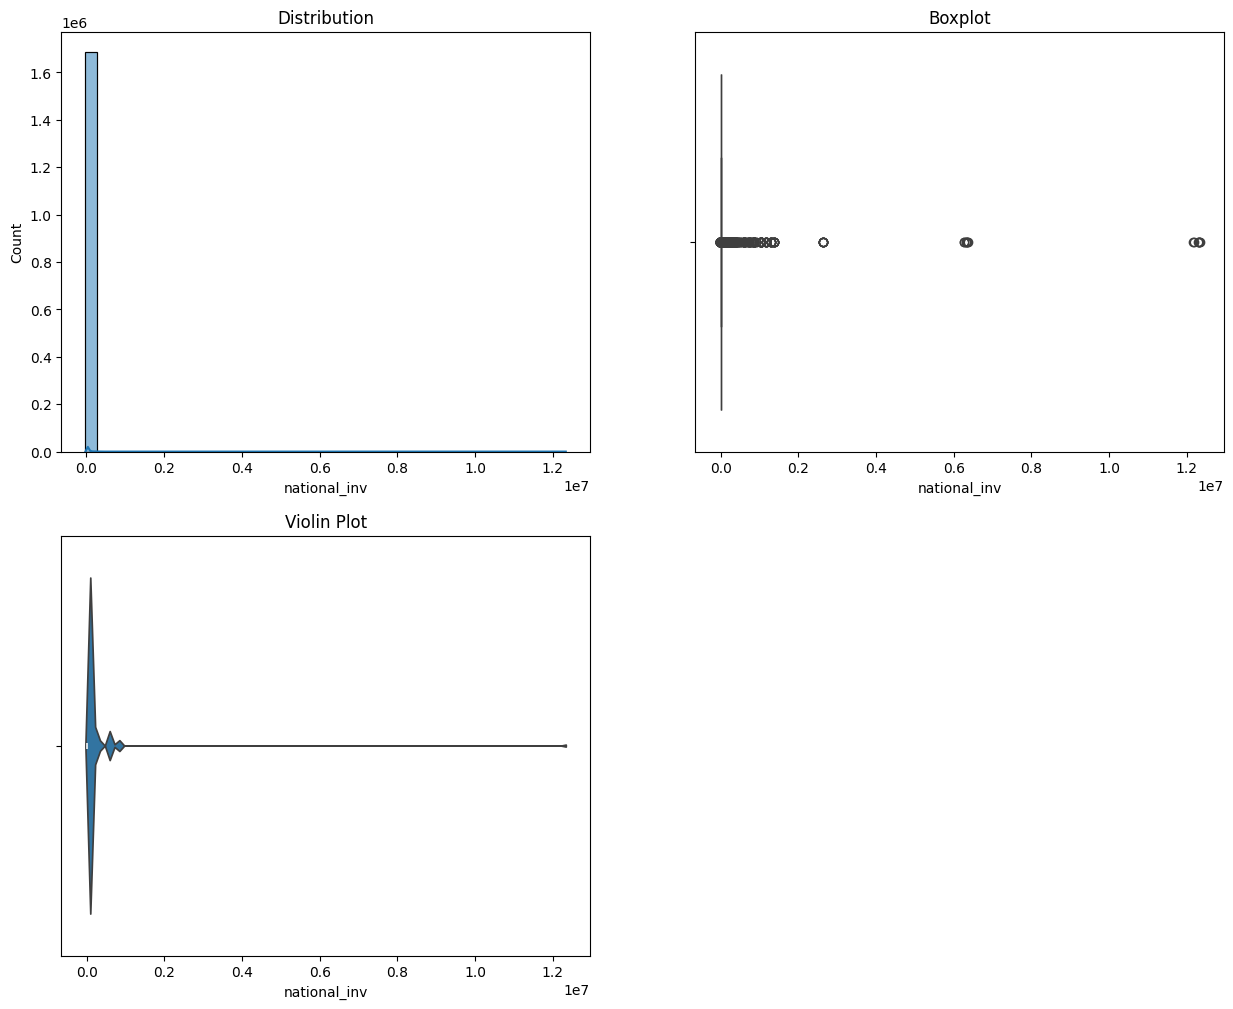

In [85]:
distribution_plots("national_inv")

Most products have very low inventory (median = 15), while a tiny few hold extreme stock (max = 12.3M) → skewness = 340 (extreme right skew). This makes national_inv an important risk feature (low inventory → backorder risk), and a log transformation (np.log1p) is recommended to reduce outlier impact.

In [86]:
df["went_on_backorder"]=df["went_on_backorder"].map({"Yes":1,"No":0})

print(df[["national_inv","went_on_backorder"]].corr())

                   national_inv  went_on_backorder
national_inv           1.000000          -0.001315
went_on_backorder     -0.001315           1.000000


`Interpretation`

Correlation close to ±1 indicates a stronger linear relationship, while values near 0 indicate a weak linear relationship. 

Keep in mind that backorder prediction is often non-linear, so a low correlation does not necessarily mean the feature is unimportant.

`Business Interpretation `

The mean inventory is much larger than the median, indicating a strongly right-skewed distribution.
Most products have low inventory, while a small number have extremely high stock levels.
Several outliers represent products with unusually large inventories.
Products that eventually go on backorder tend to have lower inventory than products that do not.
This makes national_inv an important predictive feature. Because of the strong skewness, applying a log transformation (np.log1p) may improve model performance for some algorithms.

In [87]:
# how many products have zero or near-zero inventory
zero_inventory = df[df['national_inv'] == 0].shape[0]
near_zero_5=df[df['national_inv'] < 5].shape[0]
near_zero_10 = df[df['national_inv'] < 10].shape[0]

print(f"Products with zero inventory: {zero_inventory}")
print(f"Products with near-zero inventory (5): {near_zero_5}")
print(f"Products with near-zero inventory (10): {near_zero_10}")

Products with zero inventory: 108425
Products with near-zero inventory (5): 441176
Products with near-zero inventory (10): 673871


In [16]:
# high Inventory Products:
inventory=df['national_inv']
threshold=inventory.quantile(0.99)
high_inventory = df[df["national_inv"] >= threshold]

print(f"\nTop 1% Inventory Threshold: {threshold:.2f}")

print(f"Products with Very High Inventory: {len(high_inventory):,}")

print("\nTop 10 Products with Highest Inventory")

print(high_inventory[["sku","national_inv"]].sort_values("national_inv", ascending=False).head(10))


Top 1% Inventory Threshold: 5480.00
Products with Very High Inventory: 16,887

Top 10 Products with Highest Inventory
             sku  national_inv
19894    1131381    12334404.0
1202613  1572933    12324456.0
461932   1809916    12315072.0
697605   2045597    12309096.0
735434   2083371    12285100.0
1437082  3026620    12181612.0
1595863  3191892    12166440.0
77764    1189266     6363276.0
1148188  1514455     6352932.0
396103   1744065     6335300.0


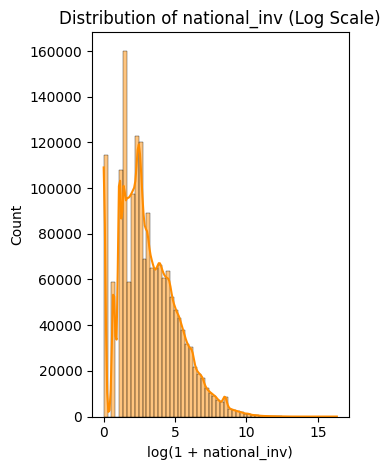

In [17]:
# Plot : Log-scale distribution (better for extreme values)
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['national_inv'].clip(lower=0)), bins=60, kde=True, color='darkorange')
plt.title("Distribution of national_inv (Log Scale)")
plt.xlabel("log(1 + national_inv)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

After applying the log transformation, the hidden structure of national_inv becomes visible: instead of one single spike at zero, the distribution is multimodal, with several peaks at low log values (0–5, i.e. real inventory ≈ 0–150 units), showing that most products are stocked at small, discrete inventory levels. The distribution remains right-skewed but is now readable, with the mass concentrated between log values 1 and 6 (≈ 2–400 units) and only a thin tail beyond 10 (inventory > 20,000), confirming that extreme stock levels are very rare. This is why the log scale is recommended: it reduces the dominance of outliers, reveals the multi-peak inventory policy structure, and produces a more manageable spread for visualization and for some modeling algorithms. 

**Note**

np.log1p(df['national_inv'].clip(lower=0)) — negative values (min = -27,256) are clipped to 0 first, because log1p is undefined for values ≤ -1.

#### <u>2- lead_time :</u>
If a product takes a long time to arrive, it is much easier to run out of stock before the new shipment arrives.
Example

Inventory = 5

Daily sales = 2

Lead Time = 20 days

You will sell

2 × 20 = 40 products

but only have 5.

Backorder is very likely.

In [90]:
# 2- lead_time:
descriptive_stats("lead_time")

Mean Inventory : 7.87
Median Inventory: 8.00
Minimum Inventory: 0.0
Maximum Inventory: 52.0
Standard Deviation : 7.056023997746594
Range : 52.0
percentiles : 
0.25     4.0
0.50     8.0
0.75     9.0
0.90    12.0
0.95    12.0
0.99    52.0
Name: lead_time, dtype: float64
Skewness: 4.556295427885092
Kurtosis: 26.237227504207393


`interpretation :`
- Mean < Median -> suggest Left skewed , but only slightly.
Skewness = 4.55 → confirms strong right skew due to extreme high values.
The contradiction is resolved once you realize outliers dominate skewness more than mean/median comparison.
- min = 0 -> some products can be replenished immediatley 

- 25% of products need just 4 days or less to arrive 
- 90% : only the slowest 10% of suppliers need more than 12 days (need attention)

- -99% = max :Only 1% of products require more than 52 days.

- STD ≈ 0 → Data is very consistent (almost all values equal).

Small STD compared to mean → Stable distribution.

Large STD compared to mean → High variability, unpredictable.

If STD is low: Most products have similar lead times → easier to plan inventory.



In [91]:
detect_outiliers("lead_time")

Outliers count: 35443


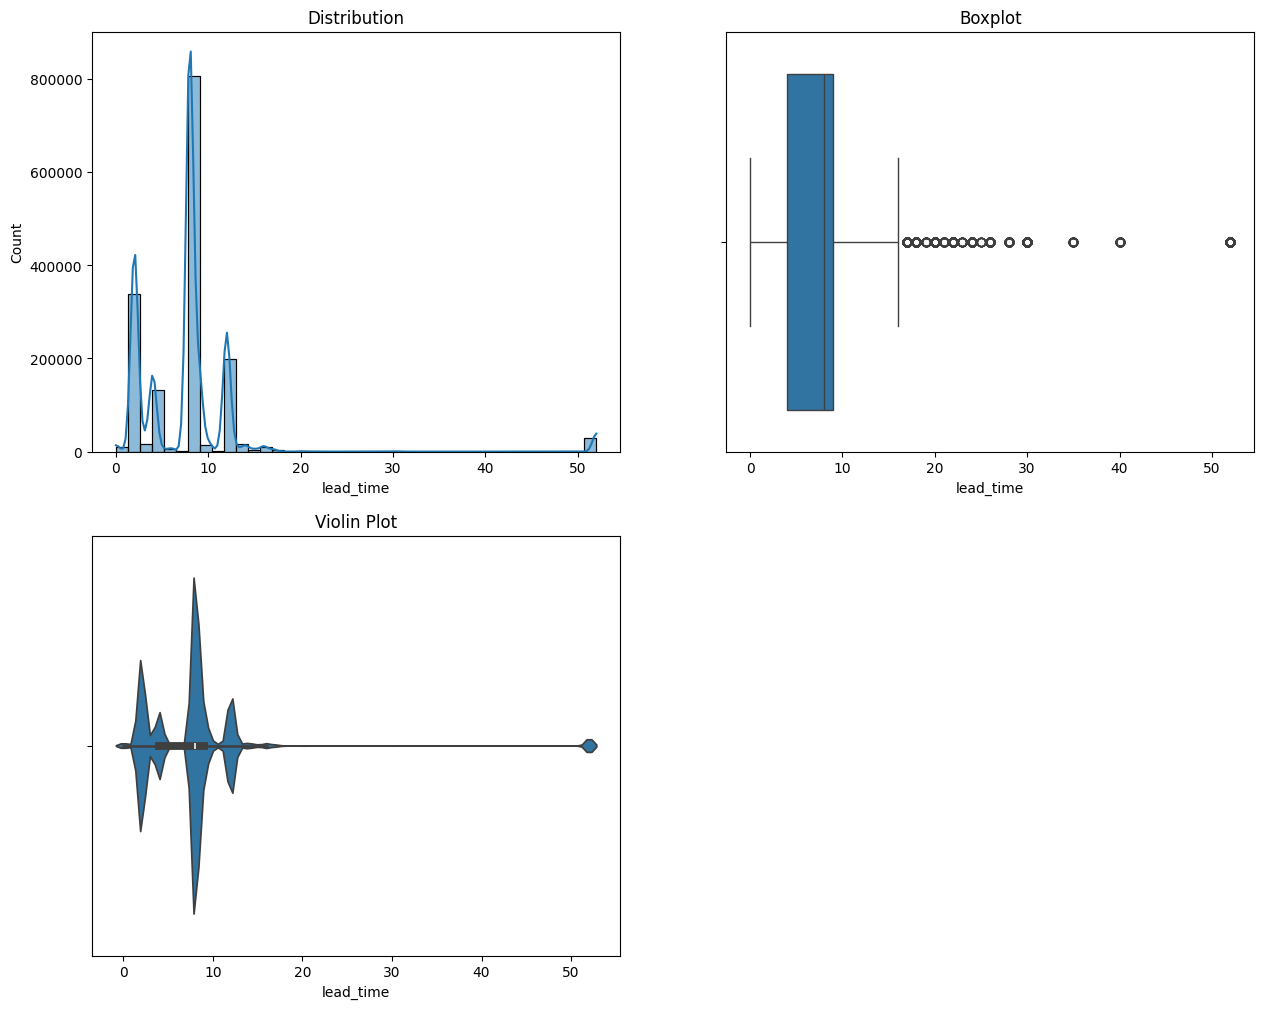

In [92]:
distribution_plots("lead_time")

The distribution of lead_time is multimodal and discrete, with clear peaks at around 2, 4, 8, and 12 days — the peak at 8 days being dominant (870,000 products) — which shows that lead times are not continuous but grouped around a few standard supplier delivery times. The boxplot confirms that most products have short lead times (median = 8, IQR ≈ 4–9 days), while **35,443 outliers** stretch to the right up to 52 days, producing a strong right skew (skewness ≈ 4.56). In short, the majority of products can be replenished quickly (≤ 12 days), but a small group of products with unusually long or extreme lead times (up to 52 days) — combined with missing values that indicate no available supplier — represents the highest backorder risk. 🎯

#### <u>3- in transit_qty:</u>
Number of units currently being shipped to the warehouse.

They have already been ordered, but have not arrived yet.

In [93]:
descriptive_stats("in_transit_qty")

Mean Inventory : 44.05
Median Inventory: 0.00
Minimum Inventory: 0.0
Maximum Inventory: 489408.0
Standard Deviation : 1342.7417307295893
Range : 489408.0
percentiles : 
0.25      0.0
0.50      0.0
0.75      0.0
0.90     16.0
0.95     68.0
0.99    570.0
Name: in_transit_qty, dtype: float64
Skewness: 166.18340424761558
Kurtosis: 39606.10405290814


`interpretation ` 
- Mean → On average, about 44 units are in transit.

- Median = 0.00 → Half of the products have no units in transit.

- min = 0 → Many products have nothing coming.

- max = 489408.0 → One product has an extremely large shipment.

- Standard Deviation → Very high spread; values vary a lot.

Percentiles:

25%, 50%, 75% → all 0 → most products have no shipments.

90% → 16 units.

95% → 68 units.

99% → 570 units.

Beyond 99% → extreme outliers 

Skewness = 166.18 → Extremely right-skewed (long tail to the right).

Kurtosis = 39,606 → Very heavy tails; extreme outliers dominate.

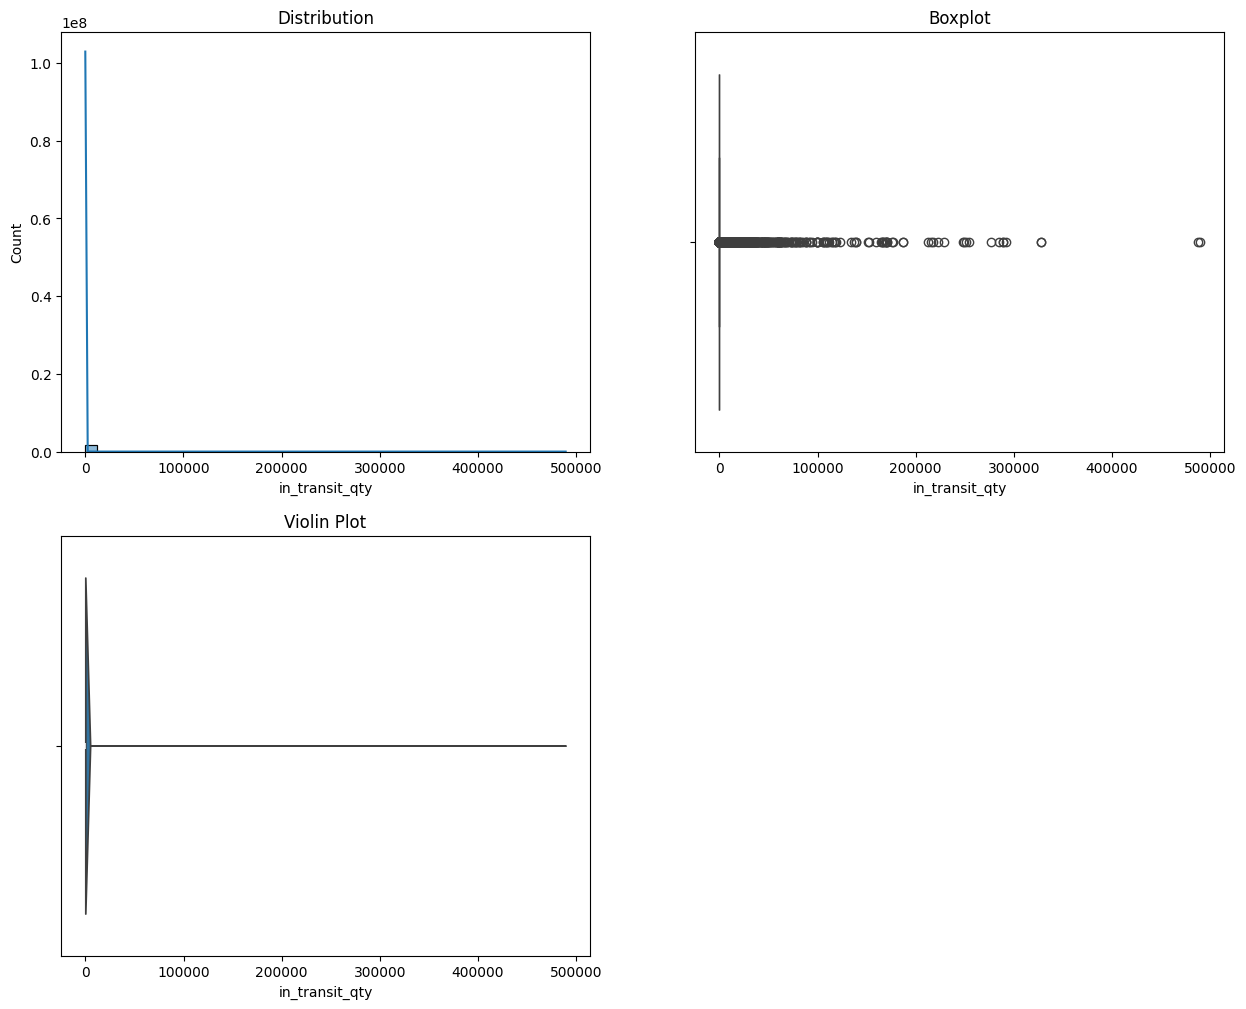

In [94]:
distribution_plots("in_transit_qty")

**Distribution (Histogram):**

The histogram shows a massive spike at 0 with an extremely long right tail stretching to ~490,000, indicating a strong right skew. This means the vast majority of products have no incoming shipments, while only a tiny few have large quantities on the way.

**Boxplot:**
The box is completely compressed at 0 (median and IQR ≈ 0), with many outlier dots spreading to the right up to ~489,408. This confirms that most products have nothing in transit, and only extreme outliers dominate the high values.

**Violin Plot:**

The violin shows nearly all the density concentrated at 0, with a very long, thin tail extending to the right. This confirms an extremely right-skewed distribution where almost no products have significant incoming stock.

#### <u>4-forecast_3/6/9_month</u>

In [ ]:
forecast_cols = ["forecast_3_month","forecast_6_month","forecast_9_month"]

df[forecast_cols].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
forecast_3_month,1687860.0,178.119284,5026.553102,0.0,0.0,0.0,4.0,83.0,300.0,2286.0,1427612.0
forecast_6_month,1687860.0,344.986664,9795.151861,0.0,0.0,0.0,12.0,176.0,600.0,4332.0,2461360.0
forecast_9_month,1687860.0,506.364431,14378.923562,0.0,0.0,0.0,20.0,261.0,896.0,6310.0,3777304.0


- Median = 0 for all → At least half of products are forecasted to have no demand in the next 3, 6, or 9 months.
→ This suggests many items are slow-moving or inactive.

- Mean much higher than median  → Strong right skew

Mean increases with horizon 

- Standard deviation grows with horizon
- Percentiles show growth

90th percentile: 83 → 176 → 261

95th percentile: 300 → 600 → 896

99th percentile: 2,286 → 4,332 → 6,310
→ Demand forecasts scale upward over longer horizons.


- Maximum values are extreme:Millions of units forecasted for a few products.

These are clear outliers and distort the distribution



**Business Interpretation**

Short-term (3M): Most products have no demand; only a few show small forecasts.

Medium-term (6M): More products show demand, forecasts grow larger.

Long-term (9M): Forecasts expand further, but dominated by extreme outliers.

Together, this means:

The dataset is highly imbalanced — many products with zero demand, a few with massive demand.

Forecasts are right-skewed and unstable over longer horizons.

For prediction, you should transform these features (log-scale or binning) to reduce outlier impact.

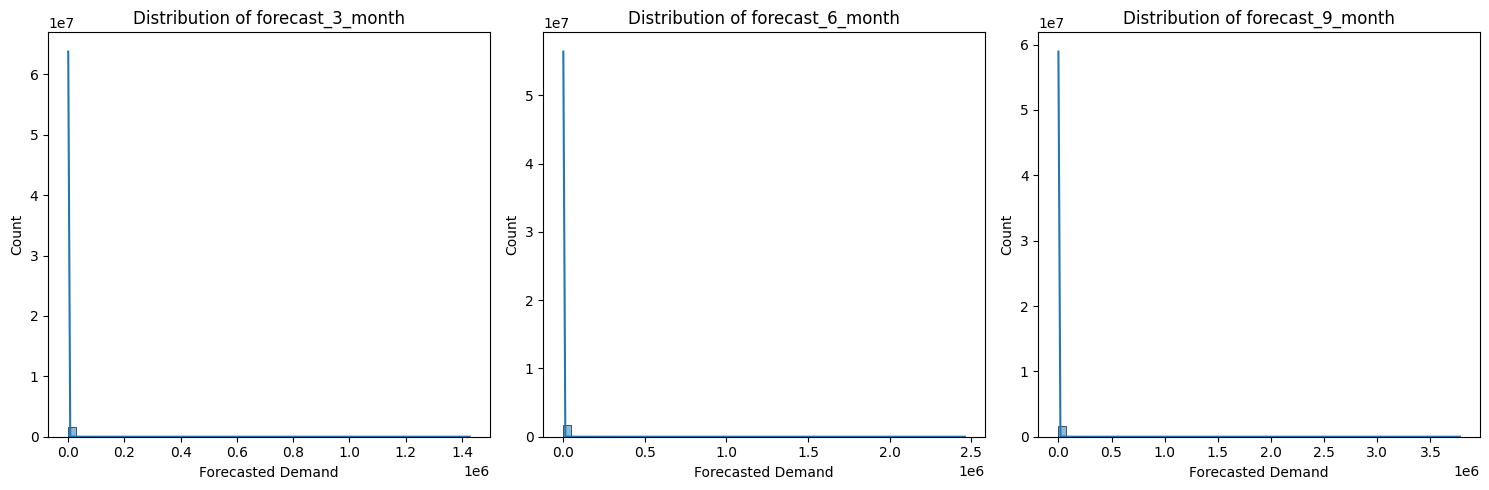

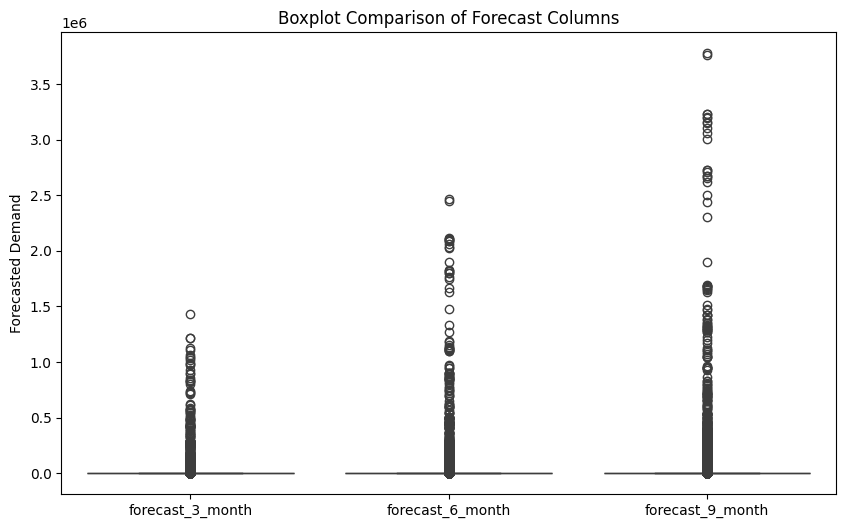

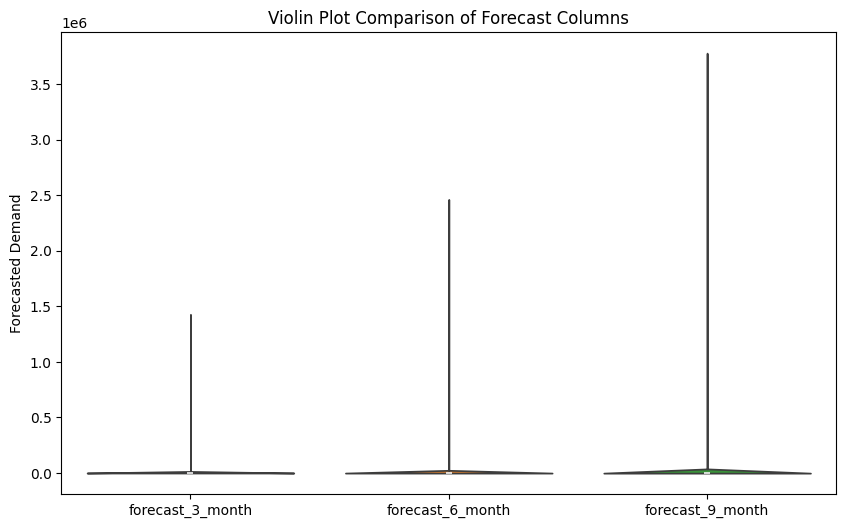

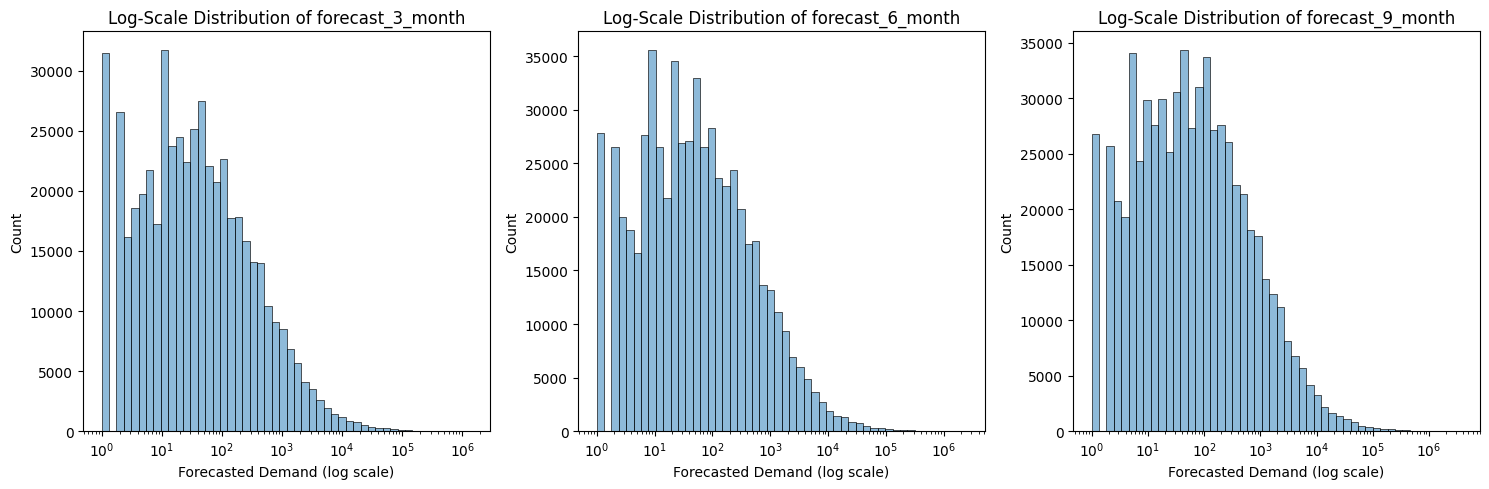

In [96]:
# 1. Histograms side by side
plt.figure(figsize=(15,5))
for i, col in enumerate(forecast_cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Forecasted Demand")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Boxplots together
plt.figure(figsize=(10,6))
sns.boxplot(data=df[forecast_cols])
plt.title("Boxplot Comparison of Forecast Columns")
plt.ylabel("Forecasted Demand")
plt.show()

# 3. Violin plots together
plt.figure(figsize=(10,6))
sns.violinplot(data=df[forecast_cols])
plt.title("Violin Plot Comparison of Forecast Columns")
plt.ylabel("Forecasted Demand")
plt.show()

# 4. Log-scale histograms (to handle extreme outliers)
plt.figure(figsize=(15,5))
for i, col in enumerate(forecast_cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[col], bins=50, kde=True, log_scale=True)
    plt.title(f"Log-Scale Distribution of {col}")
    plt.xlabel("Forecasted Demand (log scale)")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Business Interpretation**

The three forecast variables are also strongly correlated because they measure the same underlying concept at different time horizons. Products with higher forecasted demand are more likely to experience backorders if inventory and replenishment are insufficient, making these features highly valuable for prediction.

#### <u>5- sales_1/3/6/9_month</u>


In [ ]:
sales_cols = ['sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month']
df[sales_cols].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
sales_1_month,1687860.0,55.926069,1928.195879,0.0,0.0,0.0,4.0,34.0,107.0,699.0,741774.0
sales_3_month,1687860.0,175.025930,5192.377625,0.0,0.0,1.0,15.0,114.0,350.0,2233.0,1105478.0
sales_6_month,1687860.0,341.728839,9613.167104,0.0,0.0,2.0,31.0,232.0,696.0,4403.0,2146625.0
sales_9_month,1687860.0,525.269701,14838.613523,0.0,0.0,4.0,47.0,355.0,1060.0,6699.0,3205172.0


- The average sales increase with the time horizon:This is expected because sales accumulate over time.

- Mean > Median:

Most products have very low or zero sales.
A small number of products have extremely high sales.
Therefore: The distributions are strongly right-skewed.


- The standard deviation is much larger than the mean for every column.

Example:

Mean = 55 | Std = 1928

This indicates extremely high variability in sales.

Some products sell only a few units, while others sell hundreds of thousands or even millions of units.

Product demand varies enormously across the catalog.

- Min = 0 :Some products sold no units during the corresponding period.

Possible reasons:

New products
Seasonal products
Discontinued products
Very low-demand items

- 25%: At least 25% of products recorded zero sales during each time period.
- 50%:Half of the products sold:

no units in the last month,
one unit or fewer in the last three months,
two units or fewer in the last six months,
four units or fewer in the last nine months.

This confirms that most products are slow movers.

- 90th Percentile : Only the top 10% of products sold more than these values.


**Business Interpretation**

The sales_1_month, sales_3_month, sales_6_month, and sales_9_month variables describe historical product demand over different time horizons. As expected, the average sales increase as the observation period becomes longer because sales accumulate over time. The median sales remain very low compared with the means, indicating that most products sell only a few units while a small number of products account for exceptionally high sales. This results in highly right-skewed distributions with substantial variability and many extreme values. These high-sales products are likely to be key business items rather than data errors. Historical sales are essential for backorder prediction because products with consistently high demand are more likely to experience stock shortages if inventory replenishment is not sufficient. When combined with forecast demand, inventory levels, lead time, and incoming shipments, these variables provide valuable information for identifying products at risk of backorder

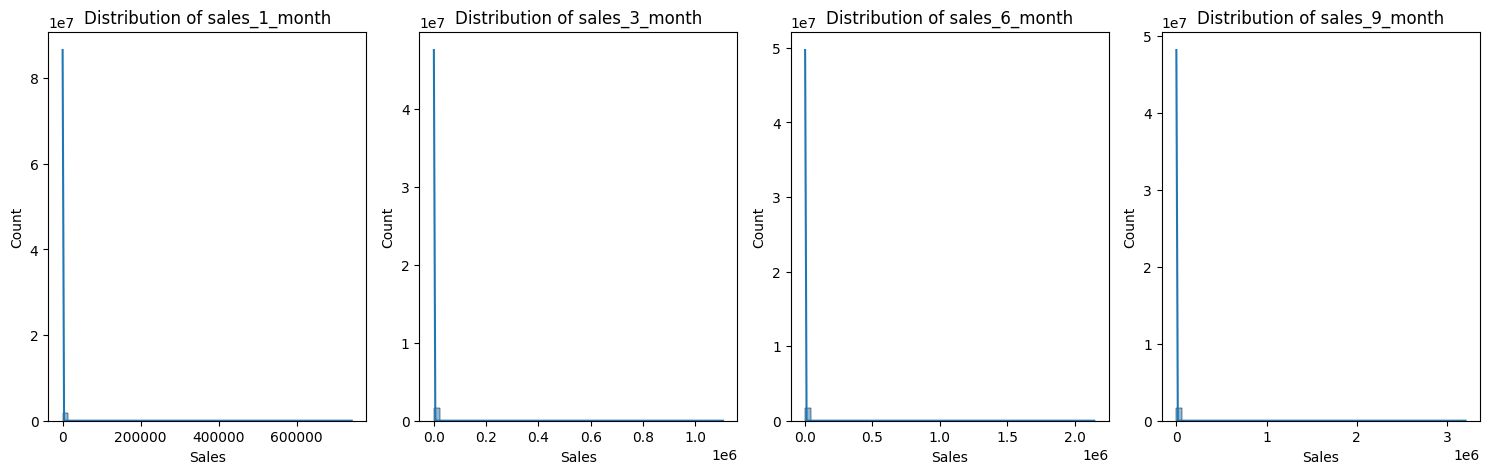

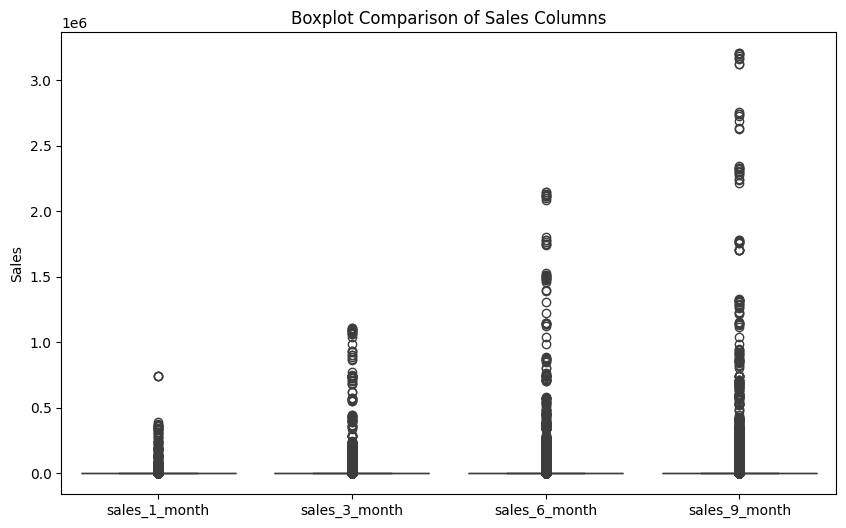

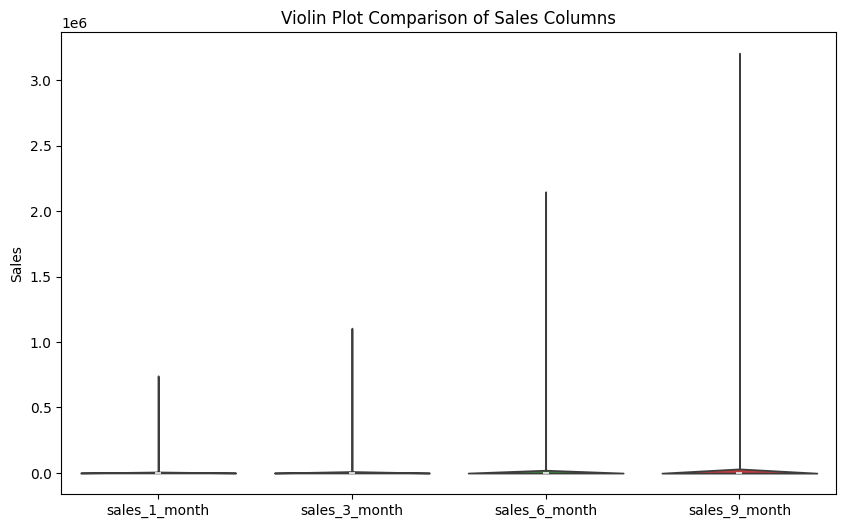

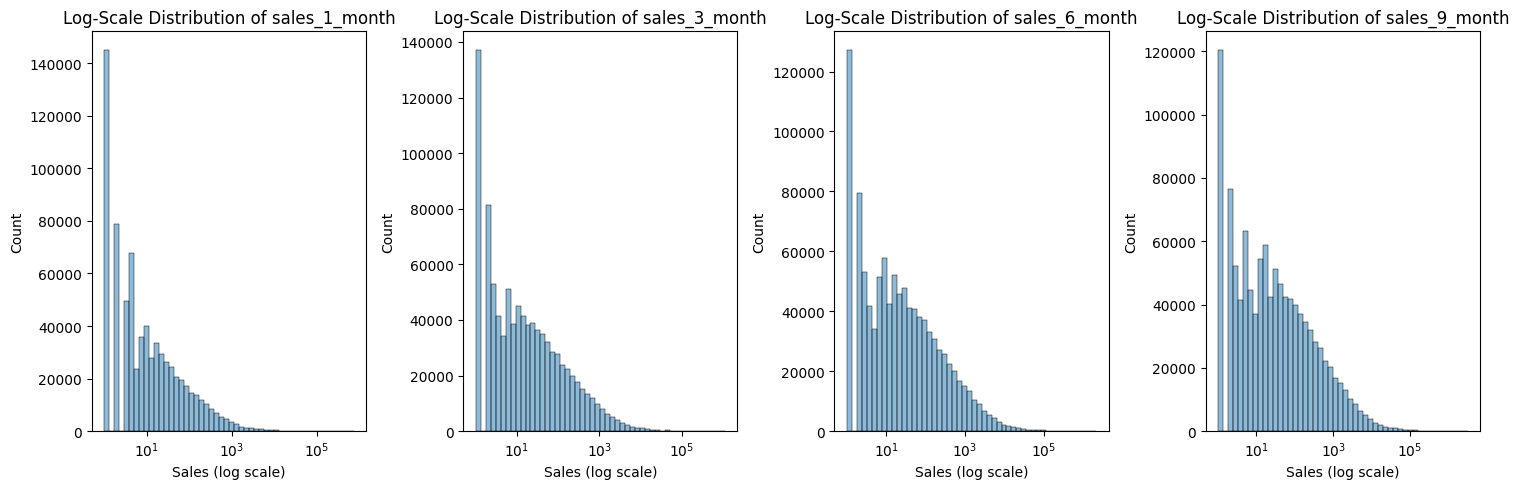

In [99]:
# 1. Histograms side by side
plt.figure(figsize=(15,5))
for i, col in enumerate(sales_cols, 1):
    plt.subplot(1,4,i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Sales")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Boxplots together
plt.figure(figsize=(10,6))
sns.boxplot(data=df[sales_cols])
plt.title("Boxplot Comparison of Sales Columns")
plt.ylabel("Sales")
plt.show()

# 3. Violin plots together
plt.figure(figsize=(10,6))
sns.violinplot(data=df[sales_cols])
plt.title("Violin Plot Comparison of Sales Columns")
plt.ylabel("Sales")
plt.show()

# 4. Log-scale histograms (to handle extreme outliers)
plt.figure(figsize=(15,5))
for i, col in enumerate(sales_cols, 1):
    plt.subplot(1,4,i)
    sns.histplot(df[col], bins=50, kde=True, log_scale=True)
    plt.title(f"Log-Scale Distribution of {col}")
    plt.xlabel("Sales (log scale)")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

**1. Histograms side by side:**

All four distributions show the same huge spike at 0 (most products sell almost nothing), but the maximum value grows with the horizon: ~740K (1M) → ~1.1M (3M) → ~2.1M (6M) → ~3.2M (9M), because sales accumulate over longer periods.

**2. Boxplots together:**

All boxes are compressed at 0, but the upper outliers stretch progressively higher as the period lengthens (0.74M → 1.1M → 2.1M → 3.2M), showing that cumulative sales amplify the extremes while the median stays near zero.

**3. Violin plots together:**

Every violin concentrates its density at 0, but the tail length increases from 1-month to 9-month, confirming that longer horizons only widen the range of extreme sellers while the bulk of products remains slow-moving.

**4. Log-scale histograms:**
On the log scale all four columns reveal the same right-skewed shape with a peak at low sales, but the spread shifts slightly to the right as the horizon grows — meaning the difference between the columns is mainly scale (accumulation), not shape.

In [100]:
# Dead stock
zero_sales = (df['sales_9_month'] == 0).sum()
print(f"\nProducts with ZERO sales in 9 months (dead stock): {zero_sales:,} ({zero_sales/len(df)*100:.2f}%)")

# Fast sellers
print(f"Products with sales_1_month > 100 : {(df['sales_1_month']>100).sum():,}")


Products with ZERO sales in 9 months (dead stock): 585,994 (34.72%)
Products with sales_1_month > 100 : 88,253


#### <u>6- min bank </u>

min_bank represents the minimum amount of inventory that the company wants to keep available as a safety/buffer level for a product.

Think of it as:

"How much stock should we ideally have available before we consider inventory too low?"
For example:

national_inv = 20
min_bank = 50

The company currently has only 20 units, while its minimum desired level is 50.

So there is a 30-unit shortfall relative to the minimum stock level.

That could be an important signal for backorder risk.

--- 

If min_bank = 10 → the company cannot order fewer than 10 units of that product.

If min_bank = 0 → no minimum restriction; they can order any quantity.

If min_bank = 100 → every replenishment order must be at least 100 units, even if demand is smaller.



---

Why it matters
Inventory planning: If demand is low but min_bank is high, the company may overstock.

Backorder risk: If inventory is low and min_bank is large, replenishment may be delayed because they can’t order small urgent quantities.

Forecast alignment: Comparing min_bank with forecasted demand helps decide if the minimum order size is realistic.

In [102]:
df['min_bank'].value_counts()

min_bank
0.0       872331
1.0       252498
2.0       113010
3.0        36035
4.0        22180
           ...  
2875.0         1
6569.0         1
4646.0         1
3573.0         1
3294.0         1
Name: count, Length: 5568, dtype: int64

In [103]:
descriptive_stats("min_bank")

Mean Inventory : 52.77
Median Inventory: 0.00
Minimum Inventory: 0.0
Maximum Inventory: 313319.0
Standard Deviation : 1254.9830887315334


Range : 313319.0
percentiles : 
0.25      0.0
0.50      0.0
0.75      3.0
0.90     46.0
0.95    125.0
0.99    679.0
Name: min_bank, dtype: float64
Skewness: 131.21264893012807
Kurtosis: 23549.240091008647


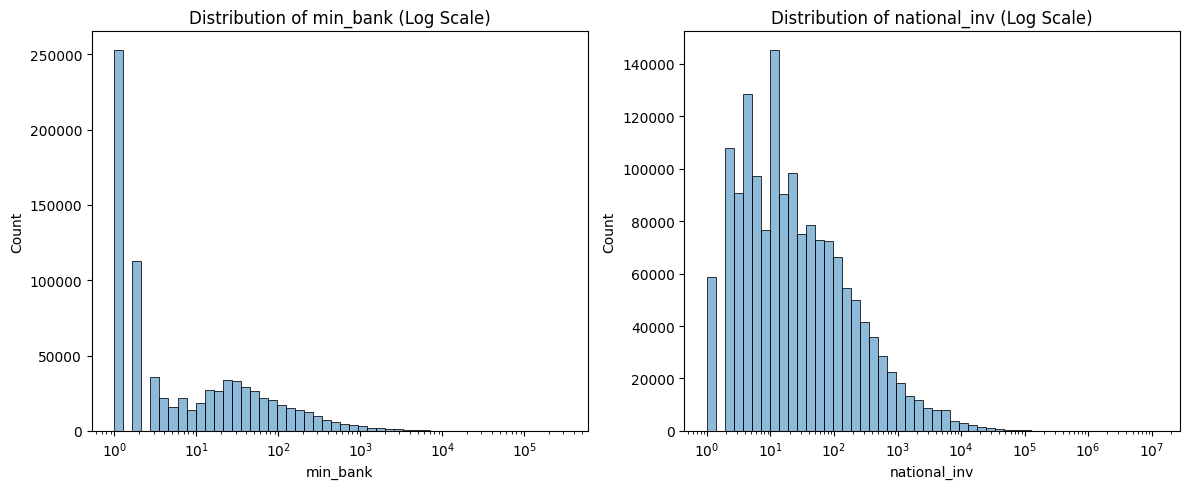

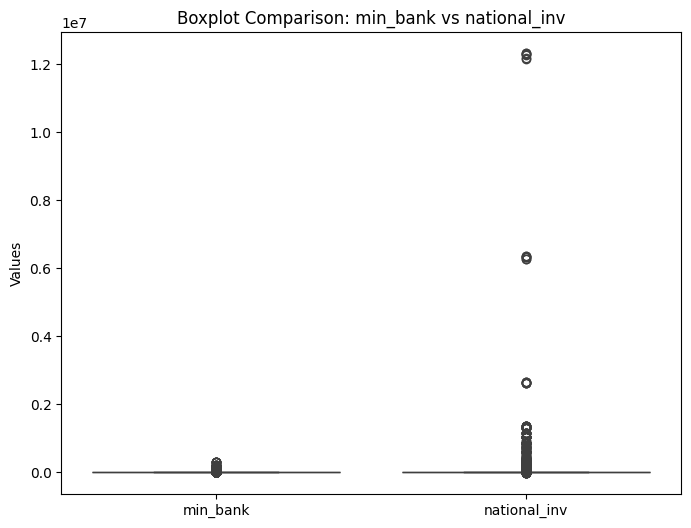

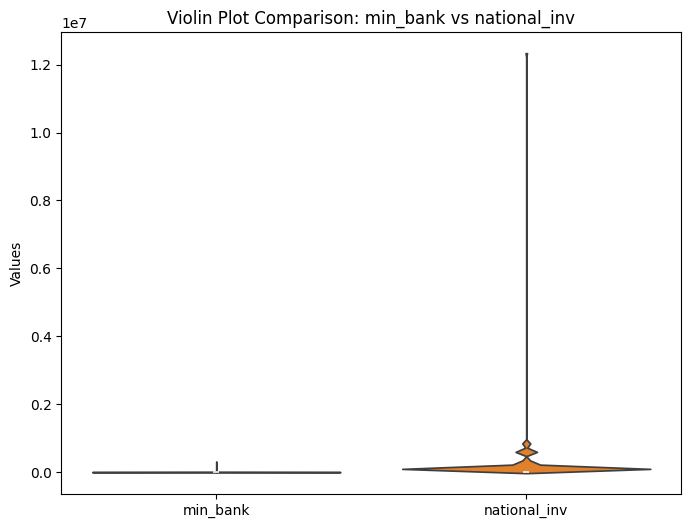

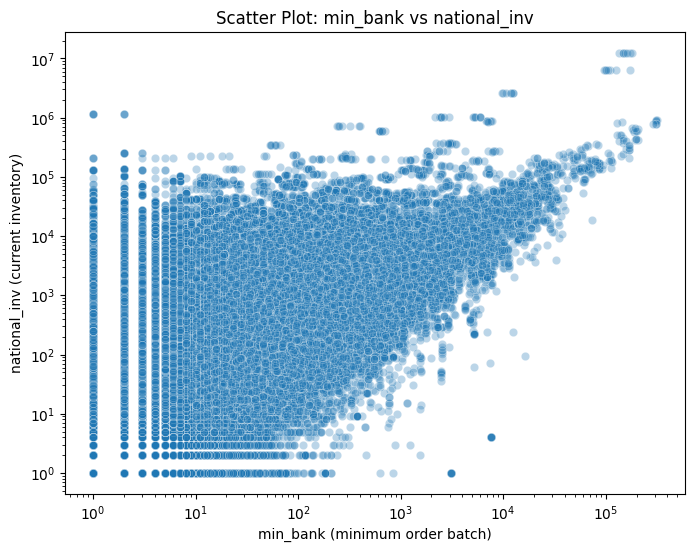

Correlation matrix:
              min_bank  national_inv
min_bank      1.000000      0.399969
national_inv  0.399969      1.000000


In [104]:
# 3. Histograms (log scale for skewed data)
cols = ["min_bank", "national_inv"]
plt.figure(figsize=(12,5))
for i, col in enumerate(cols, 1):
    plt.subplot(1,2,i)
    sns.histplot(df[col], bins=50, kde=True, log_scale=True)
    plt.title(f"Distribution of {col} (Log Scale)")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 4. Boxplots together
plt.figure(figsize=(8,6))
sns.boxplot(data=df[cols])
plt.title("Boxplot Comparison: min_bank vs national_inv")
plt.ylabel("Values")
plt.show()

# 5. Violin plots together
plt.figure(figsize=(8,6))
sns.violinplot(data=df[cols])
plt.title("Violin Plot Comparison: min_bank vs national_inv")
plt.ylabel("Values")
plt.show()

# 6. Scatter plot to compare relationship
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["min_bank"], y=df["national_inv"], alpha=0.3)
plt.title("Scatter Plot: min_bank vs national_inv")
plt.xlabel("min_bank (minimum order batch)")
plt.ylabel("national_inv (current inventory)")
plt.xscale("log")
plt.yscale("log")
plt.show()

# 7. Correlation
print("Correlation matrix:")
print(df[cols].corr())

**Scatter Plot:**

The plot shows a moderate positive trend — products with higher min_bank generally hold higher national_inv (visible in the top-right cluster) — but the cloud is extremely wide at low/mid min_bank values (1–100), where inventory ranges from 1 to over 100,000, meaning the minimum order batch alone does not determine stock levels. The most dangerous zone is the bottom-right (high min_bank but national_inv ≈ 1–10): products whose current inventory is far below their required minimum → strong backorder risk signal.

**Correlation = 0.40:**

This confirms a moderate positive linear relationship (only ~16% shared variance, since 0.40² ≈ 0.16) — meaningful but not strong. This is exactly why the engineered feature below_min_bank (inventory < minimum) is more useful for prediction than the raw correlation: the gap between the two matters more than their linear relationship. 🎯

#### <u>7- potential_issue</u>

In [106]:
# Frequency counts
print(df["potential_issue"].value_counts())

potential_issue
No     1686953
Yes        907
Name: count, dtype: int64


Why it matters
Backorder prediction: Products flagged with "Yes" are more likely to go on backorder, because they already have supply chain risks.

Inventory planning: Even if inventory looks fine, a "Yes" flag warns planners to be cautious.

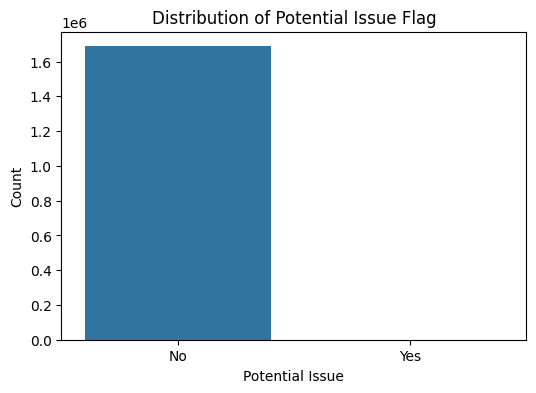

went_on_backorder      0.0    1.0
potential_issue                  
No                 1675711  11242
Yes                    856     51


In [107]:
# Plot distribution
plt.figure(figsize=(6,4))
sns.countplot(x="potential_issue", data=df)
plt.title("Distribution of Potential Issue Flag")
plt.xlabel("Potential Issue")
plt.ylabel("Count")
plt.show()

# Compare with backorder target
issue_backorder = pd.crosstab(df["potential_issue"], df["went_on_backorder"])
print(issue_backorder)

#### <u>8-piece_past_due:</u>

Number of pieces/units that were supposed to arrive but are already past their expected delivery date.

In other words: it’s the quantity of late deliveries from suppliers.

If pieces_past_due = 0 → no overdue items.

If pieces_past_due = 50 → 50 units are late and haven’t arrived yet.

**Example**:

Supplier promised 200 units by July 1.

Only 150 arrived on time.

The remaining 50 are past due → pieces_past_due = 50.

In [108]:
df['pieces_past_due'].value_counts()

pieces_past_due
0.0        1662571
1.0           3917
2.0           2187
4.0           1294
3.0           1217
            ...   
15840.0          1
291.0            1
3800.0           1
499.0            1
408.0            1
Name: count, Length: 826, dtype: int64

In [109]:
descriptive_stats("pieces_past_due")

Mean Inventory : 2.04
Median Inventory: 0.00
Minimum Inventory: 0.0
Maximum Inventory: 146496.0
Standard Deviation : 236.01649969344106
Range : 146496.0
percentiles : 
0.25    0.0
0.50    0.0
0.75    0.0
0.90    0.0
0.95    0.0
0.99    4.0
Name: pieces_past_due, dtype: float64
Skewness: 412.3919003925264
Kurtosis: 207663.22584158805


**Summary of Results**

Mean = 2.04 → On average, only about 2 units are overdue per product.

Median = 0.00 → At least half of products have no overdue pieces at all.

Minimum = 0.0 → Some products are perfectly on time.

Maximum = 146,496.0 → A few products have extremely large overdue quantities.

Standard Deviation = 236.0 → Very high variability compared to the mean (shows instability).

Range = 146,496.0 → Huge spread between smallest and largest overdue values.

Percentiles:

25%, 50%, 75%, 90%, 95% = 0 → Most products have no overdue pieces.

99% = 4 → Even at the 99th percentile, only 4 overdue units.

The extreme maximum (146k) is a rare outlier.

**shape of Distribution**

Skewness = 412.39 → Extremely right-skewed. 

Kurtosis = 207,663 → Extremely peaked with heavy tails. This means the dataset has many zeros and a few extreme overdue cases.

**Interpretation**

Most products are delivered on time.

A tiny fraction of products have overdue deliveries, but when they do, the overdue quantities can be enormous (tens of thousands).

For most items, supplier reliability is fine.

For a few items, overdue deliveries are catastrophic, creating huge backorder risk.

This column is a strong risk signal: even small non-zero values increase the chance of backorder.

In [110]:
detect_outiliers("pieces_past_due")

Outliers count: 25289


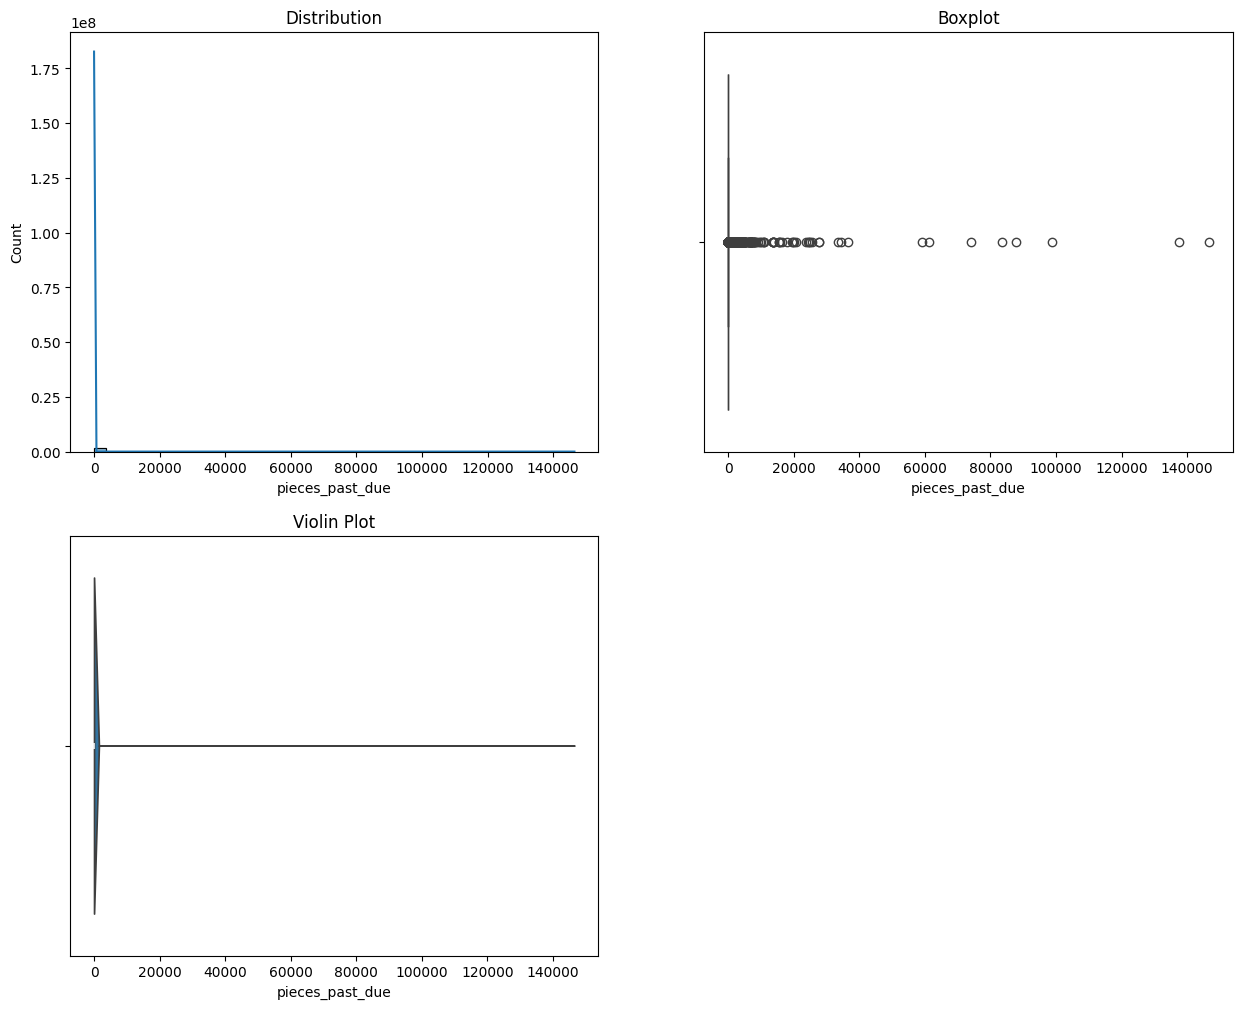

In [111]:
distribution_plots("pieces_past_due")

In [112]:
#Does having past-due units increase the probability of backorder?
has_past_due = df["pieces_past_due"] > 0

pd.crosstab(
    has_past_due,
    df["went_on_backorder"],
    normalize="index"
) * 100

went_on_backorder,0.0,1.0
pieces_past_due,,
False,99.383665,0.616335
True,95.863814,4.136186


#### <u>10-perf_6_month_avg & perf_12_month_avg</u>

- perf_6_month_avg → The supplier’s average performance score over the last 6 months.

- perf_12_month_avg → The supplier’s average performance score over the last 12 months.

These are supplier reliability indicators. They usually measure things like:

On-time delivery rate

Quality of delivered goods

Responsiveness to orders

Values are often normalized (e.g., between 0 and 1, or 0 and 100).

**Interpretation**

If 6M > 12M → supplier has improved recently.

If 6M < 12M → supplier performance has declined in the short term.

If both are high → supplier is consistently reliable.

If both are low → supplier is consistently problematic.

**Business impact**

Declining performance → higher risk of backorders.

Improving performance → more confidence in future deliveries.

Comparing these helps identify trends in supplier reliability

In [113]:
df['perf_6_month_avg'].value_counts()

perf_6_month_avg
 0.99     143757
 1.00     132329
-99.00    129478
 0.73     106468
 0.98      83611
           ...  
 0.20        861
 0.03        703
 0.04        652
 0.01        572
 0.29        515
Name: count, Length: 102, dtype: int64

In [114]:
# 1. Summary statistics
perf_cols = ['perf_6_month_avg', 'perf_12_month_avg']
summary = df[perf_cols].describe(percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]).T
summary

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
perf_6_month_avg,1687860.0,-6.872059,26.556357,-99.0,0.63,0.82,0.97,0.99,1.00,1.0,1.0
perf_12_month_avg,1687860.0,-6.437947,25.843331,-99.0,0.66,0.81,0.95,0.99,0.99,1.0,1.0


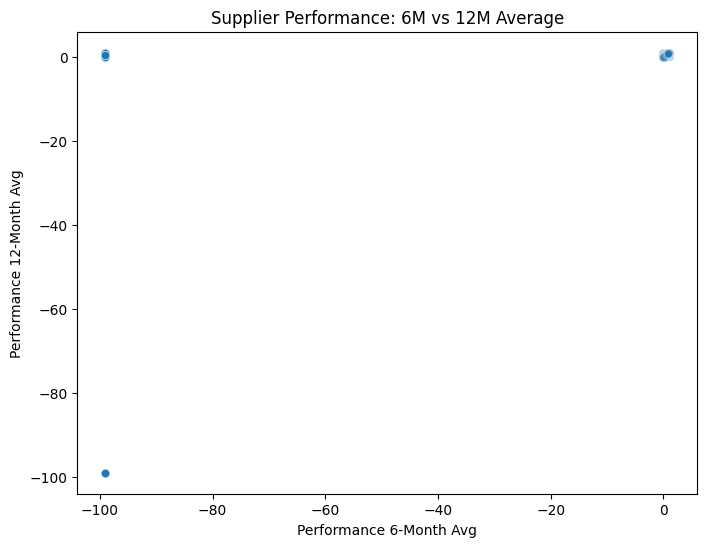

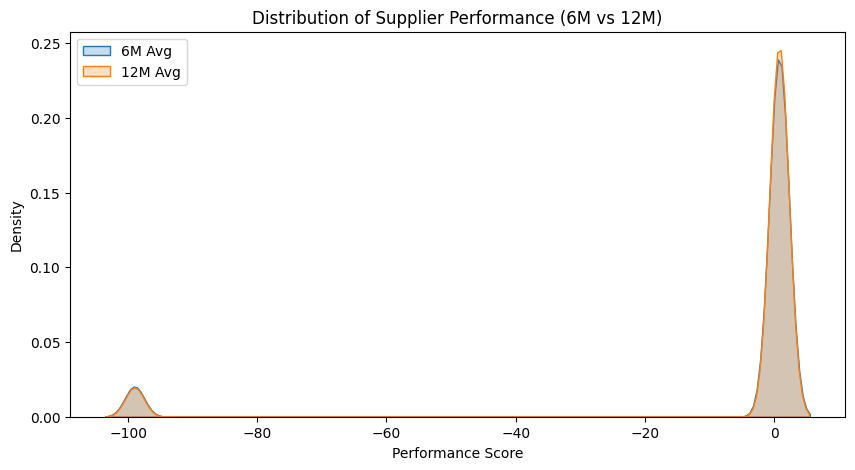

In [ ]:
# 3. Scatter plot comparison
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["perf_6_month_avg"], y=df["perf_12_month_avg"], alpha=0.3)
plt.title("Supplier Performance: 6M vs 12M Average")
plt.xlabel("Performance 6-Month Avg")
plt.ylabel("Performance 12-Month Avg")
plt.show()

# 4. Distribution plots
plt.figure(figsize=(10,5))
sns.kdeplot(df["perf_6_month_avg"], label="6M Avg", shade=True)
sns.kdeplot(df["perf_12_month_avg"], label="12M Avg", shade=True)
plt.title("Distribution of Supplier Performance (6M vs 12M)")
plt.xlabel("Performance Score")
plt.ylabel("Density")
plt.legend()
plt.show()


- The two curves (6M and 12M) almost perfectly overlap → supplier reliability is very stable over time; short-term and long-term performance tell the same story (no major improvement or decline).
- Bimodal distribution: the large peak near 0–1 = the vast majority of suppliers have high fill rates (mostly 0.6–1.0, concentrated around 0.8–1.0); the small peak at −99 = missing data (no supplier / no performance history, ~7.7% of products), not a real performance score.

Business meaning: Most suppliers are consistently reliable, so performance alone separates few products — but products with perf = −99 should be treated as a risk flag (no measurable supplier → potentially no way to replenish → higher backorder risk). 🎯

#### <u>11- Local_bo_qty:</u>

local_bo_qty = Local Backorder Quantity

It represents the number of units currently on backorder at the local warehouse or distribution center.

In other words: how many pieces customers have ordered but cannot be fulfilled immediately because stock is unavailable locally.

**Example**

Customer orders 50 units.

Local warehouse has only 30 units in stock.

The missing 20 units go into local backorder → local_bo_qty = 20.

In [118]:
df['local_bo_qty'].value_counts()

local_bo_qty
0.0       1664518
1.0          7151
2.0          2982
3.0          1716
4.0          1224
           ...   
5200.0          1
1037.0          1
931.0           1
511.0           1
3600.0          1
Name: count, Length: 654, dtype: int64

In [119]:
descriptive_stats("local_bo_qty")

Mean Inventory : 0.63
Median Inventory: 0.00
Minimum Inventory: 0.0
Maximum Inventory: 12530.0
Standard Deviation : 33.722241562091185
Range : 12530.0
percentiles : 
0.25    0.0
0.50    0.0
0.75    0.0
0.90    0.0
0.95    0.0
0.99    1.0
Name: local_bo_qty, dtype: float64
Skewness: 165.19054793748316
Kurtosis: 38154.95545739713


In [120]:
print(f"\nProducts with local backorders > 0 : {(df['local_bo_qty']>0).sum():,} ({(df['local_bo_qty']>0).mean()*100:.2f}%)")


Products with local backorders > 0 : 23,342 (1.38%)


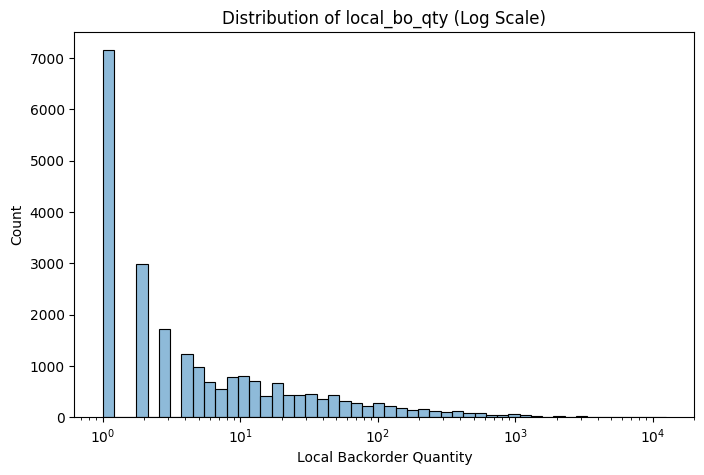

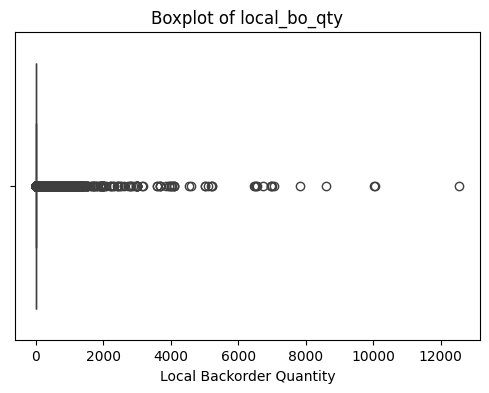

went_on_backorder      0.0   1.0
local_bo_qty                    
False              1654624  9894
True                 21943  1399


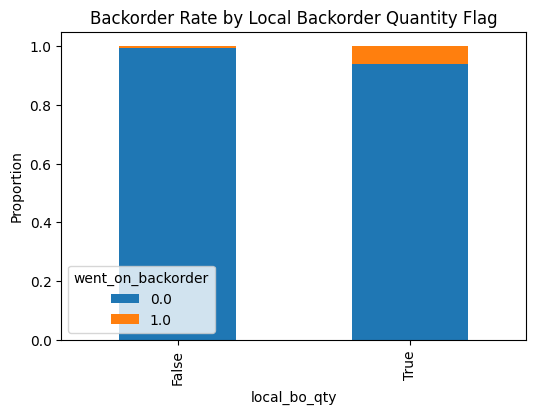

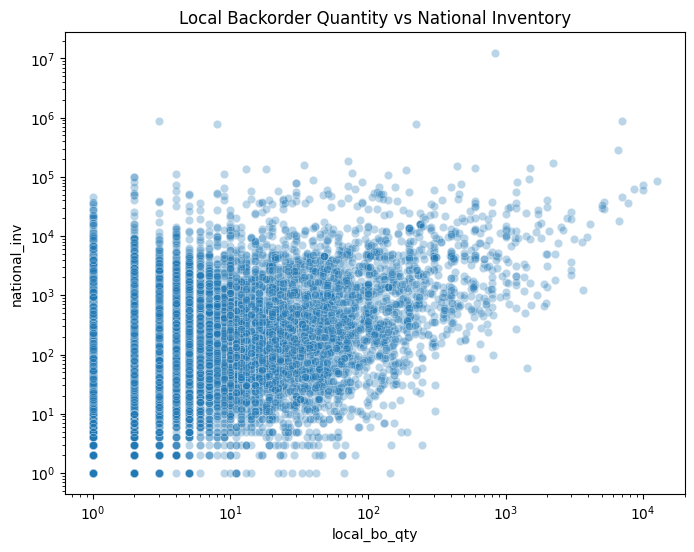

Correlation with national_inv:
              local_bo_qty  national_inv
local_bo_qty      1.000000      0.014887
national_inv      0.014887      1.000000


In [121]:
# 3. Histogram (log scale for skewed data)
plt.figure(figsize=(8,5))
sns.histplot(df["local_bo_qty"], bins=50, kde=True, log_scale=True)
plt.title("Distribution of local_bo_qty (Log Scale)")
plt.xlabel("Local Backorder Quantity")
plt.ylabel("Count")
plt.show()

# 4. Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df["local_bo_qty"])
plt.title("Boxplot of local_bo_qty")
plt.xlabel("Local Backorder Quantity")
plt.show()

# 5. Relation with backorder target
crosstab = pd.crosstab(df["local_bo_qty"] > 0, df["went_on_backorder"])
print(crosstab)

crosstab_norm = crosstab.div(crosstab.sum(1), axis=0)
crosstab_norm.plot(kind="bar", stacked=True, figsize=(6,4))
plt.title("Backorder Rate by Local Backorder Quantity Flag")
plt.ylabel("Proportion")
plt.show()

# 6. Compare with national inventory
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["local_bo_qty"], y=df["national_inv"], alpha=0.3)
plt.title("Local Backorder Quantity vs National Inventory")
plt.xlabel("local_bo_qty")
plt.ylabel("national_inv")
plt.xscale("log")
plt.yscale("log")
plt.show()

print("Correlation with national_inv:")
print(df[["local_bo_qty","national_inv"]].corr())

**Interpretation**

Most values = 0 → most products have no local backorders.

Non-zero values → indicate real shortages.

High skewness → a few products have very large backorder quantities.

Comparison with national_inv:

If local_bo_qty > 0 and national_inv is also low → severe shortage.

If local_bo_qty > 0 but national_inv is high → stock exists nationally but not locally (distribution issue).

**In short:**

It’s one of the most direct indicators of shortage risk.

Comparing it with national_inv tells you whether the problem is a true stockout or just a local distribution imbalance.


#### <u>12- Risk Flags </u>

- deck_risk ->This is a risk flag indicating whether the product has a particular supply/operational risk classified as "deck risk."


- oe_constraint ->An OE constraint is a flag indicating that the product is affected by an operational constraint.

For example, there could be a constraint related to:
production
manufacturing
supplier operations
availability

- ppap_risk:Production Part Approval Process (used in automotive and manufacturing). This flag indicates whether the part has approval/compliance risks (e.g., supplier hasn’t completed required documentation/testing).

- stop-auto_buy:This flag means the system has stopped automatic purchasing for the product. Normally, the ERP system can auto‑trigger replenishment orders when inventory drops. 

If this flag = “Yes”, auto‑buy is disabled — the product will not be reordered automatically.

- rev_stop:is a flag indicating a revision/stop condition associated with the product.

For example:

rev_stop = Yes

could indicate that the product is subject to a revision/stop status.

In [122]:
risk_flags = ['deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']
for col in risk_flags:
    print(f"{col}:")
    result=pd.crosstab(df[col],df['went_on_backorder'],normalize="index") * 100
    print(result)
    print("_"*60)


deck_risk:
went_on_backorder        0.0       1.0
deck_risk                             
No                 99.278901  0.721099
Yes                99.505527  0.494473
____________________________________________________________
oe_constraint:
went_on_backorder        0.0       1.0
oe_constraint                         
No                 99.331305  0.668695
Yes                96.734694  3.265306
____________________________________________________________
ppap_risk:
went_on_backorder        0.0       1.0
ppap_risk                             
No                 99.357558  0.642442
Yes                99.137043  0.862957
____________________________________________________________
stop_auto_buy:
went_on_backorder        0.0       1.0
stop_auto_buy                         
No                 99.228956  0.771044
Yes                99.334757  0.665243
____________________________________________________________
rev_stop:
went_on_backorder         0.0       1.0
rev_stop                      

Overall Insights
Most flags are weak predictors: Their backorder rates are very close to the baseline (~0.6–0.7%).

oe_constraint is the exception: It shows a clear jump in backorder probability (3.3%). This makes sense — OEM supply restrictions directly limit replenishment.

Other flags (deck_risk, ppap_risk, stop_auto_buy, rev_stop) don’t show meaningful differences. They may be administrative or compliance markers that don’t translate into actual shortages.

In [123]:
#Count how many risks each product has
df_risk=df[risk_flags].map(lambda x: 1 if x == 'Yes' else 0)
df['risk_count']=df_risk.sum(axis=1)
risk_table = df[["sku"] +risk_flags + ["risk_count"]].head(10)
risk_table

,sku,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,risk_count
0,1026827,No,No,No,Yes,No,1
1,1043384,No,No,No,Yes,No,1
2,1043696,Yes,No,No,Yes,No,2
3,1043852,No,No,No,Yes,No,1
4,1044048,Yes,No,No,Yes,No,2
5,1044198,No,No,No,Yes,No,1
6,1044643,Yes,No,No,Yes,No,2
7,1045098,Yes,No,Yes,Yes,No,3
8,1045815,No,No,No,Yes,No,1
9,1045867,No,No,No,Yes,No,1


In [124]:
df["went_on_backorder"] = df["went_on_backorder"].map({"Yes":1, "No":0})

In [125]:
#Does more risk = more backorders?
risk_backorder_rate=(df.groupby('risk_count')['went_on_backorder'].mean()*100).reset_index()
risk_backorder_rate

,risk_count,went_on_backorder
0,0,NaN
1,1,NaN
2,2,NaN
3,3,NaN
4,4,NaN


In [126]:
print("Missing Values Count:")
missing_data = df.isnull().sum()
missing_data

Missing Values Count:


sku                        0
national_inv               1
lead_time             100894
in_transit_qty             1
forecast_3_month           1
forecast_6_month           1
forecast_9_month           1
sales_1_month              1
sales_3_month              1
sales_6_month              1
sales_9_month              1
min_bank                   1
potential_issue            1
pieces_past_due            1
perf_6_month_avg           1
perf_12_month_avg          1
local_bo_qty               1
deck_risk                  1
oe_constraint              1
ppap_risk                  1
stop_auto_buy              1
rev_stop                   1
went_on_backorder    1687861
risk_count                 0
dtype: int64

In [127]:
# Check for missing values represented as -99 (common in this dataset)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    count_minus_99 = (df[col] == -99).sum()
    if count_minus_99 > 0:
        print(f"{col}: {count_minus_99} values = -99 ({count_minus_99/len(df)*100:.2f}%)")

print("Note: -99 often represents missing or unavailable data")

national_inv: 3 values = -99 (0.00%)
perf_6_month_avg: 129478 values = -99 (7.67%)
perf_12_month_avg: 122050 values = -99 (7.23%)
Note: -99 often represents missing or unavailable data


In [3]:
drop_cols = [
    "deck_risk",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
    # "risk_count"
]
df.drop(columns=drop_cols, inplace=True)

### Step 3: Data Preprocessing & Cleaning

**Why Preprocessing?**
- Handle missing values (-99 notation)
- Convert categorical variables to numbers
- Scale numerical features
- Deal with class imbalance

In [4]:
df.isnull().sum()

sku                       0
national_inv              1
lead_time            100894
in_transit_qty            1
forecast_3_month          1
forecast_6_month          1
forecast_9_month          1
sales_1_month             1
sales_3_month             1
sales_6_month             1
sales_9_month             1
min_bank                  1
potential_issue           1
pieces_past_due           1
perf_6_month_avg          1
perf_12_month_avg         1
local_bo_qty              1
oe_constraint             1
went_on_backorder         1
dtype: int64

In [5]:
df_processed = df.copy()

# Replace -99 with NaN
df_processed.replace(-99, np.nan, inplace=True)

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,oe_constraint,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,NaN,NaN,0.0,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,0.99,0.99,0.0,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No,0.0,NaN,NaN,0.0,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,No,0.0,0.10,0.13,0.0,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,No,0.0,NaN,NaN,0.0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687856,1373987,-1.0,NaN,0.0,5.0,7.0,9.0,1.0,3.0,3.0,8.0,0.0,No,0.0,NaN,NaN,1.0,No,No
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,12.0,0.0,No,0.0,0.86,0.84,1.0,No,Yes
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,205.0,12.0,No,0.0,0.86,0.84,6.0,No,No
1687859,1502009,19.0,4.0,0.0,0.0,0.0,0.0,2.0,7.0,12.0,20.0,1.0,No,0.0,0.73,0.78,1.0,No,No


In [6]:
df_processed.isnull().sum()

sku                       0
national_inv              4
lead_time            100894
in_transit_qty            1
forecast_3_month          1
forecast_6_month          1
forecast_9_month          1
sales_1_month             1
sales_3_month             1
sales_6_month             1
sales_9_month             1
min_bank                  1
potential_issue           1
pieces_past_due           1
perf_6_month_avg     129479
perf_12_month_avg    122051
local_bo_qty              1
oe_constraint             1
went_on_backorder         1
dtype: int64

In [7]:
# Numeric columns
for col in df_processed.select_dtypes(include=[np.number]).columns:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        if pd.isna(median_val):   # median is NaN
            df_processed[col] = df_processed[col].fillna(0)
            print(f"Filled {col} with 0 (median was NaN)")
        else:
            df_processed[col] = df_processed[col].fillna(median_val)
            print(f"Filled {col} with median: {median_val}")

# Categorical columns
for col in df_processed.select_dtypes(include=["object"]).columns:
    if df_processed[col].isnull().sum() > 0:
        if not df_processed[col].mode().empty:
            mode_val = df_processed[col].mode()[0]
            df_processed[col] = df_processed[col].fillna(mode_val)
            print(f"Filled {col} with mode: {mode_val}")
        else:
            df_processed[col] = df_processed[col].fillna("Unknown")
            print(f"Filled {col} with 'Unknown'")

print("\nRemaining missing values:")
print(df_processed.isnull().sum())


Filled national_inv with median: 15.0
Filled lead_time with median: 8.0
Filled in_transit_qty with median: 0.0
Filled forecast_3_month with median: 0.0
Filled forecast_6_month with median: 0.0
Filled forecast_9_month with median: 0.0
Filled sales_1_month with median: 0.0
Filled sales_3_month with median: 1.0
Filled sales_6_month with median: 2.0
Filled sales_9_month with median: 4.0
Filled min_bank with median: 0.0
Filled pieces_past_due with median: 0.0
Filled perf_6_month_avg with median: 0.85
Filled perf_12_month_avg with median: 0.83
Filled local_bo_qty with median: 0.0


C:\Users\pc\AppData\Local\Temp\ipykernel_9388\3936865496.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_processed.select_dtypes(include=["object"]).columns:


Filled potential_issue with mode: No
Filled oe_constraint with mode: No
Filled went_on_backorder with mode: No

Remaining missing values:
sku                  0
national_inv         0
lead_time            0
in_transit_qty       0
forecast_3_month     0
forecast_6_month     0
forecast_9_month     0
sales_1_month        0
sales_3_month        0
sales_6_month        0
sales_9_month        0
min_bank             0
potential_issue      0
pieces_past_due      0
perf_6_month_avg     0
perf_12_month_avg    0
local_bo_qty         0
oe_constraint        0
went_on_backorder    0
dtype: int64


In [8]:
df_processed.duplicated().sum()

np.int64(0)

In [ ]:
df_processed.to_csv("../clean_csv/processed_backorder_data.csv",index=False)

# Author
### <a href="https://www.linkedin.com/in/salma-belaicha-04a646336/" target="_blank">Salma Belaicha</a>